## <div align="center"> IS388 Data Analysis </div>
## <div align="center"> Ujian Akhir Semester</div>
#### <div align="center"> Semester Ganjil 2023/2024 </div>
---

In [1]:
%pip install pandas numpy matplotlib seaborn scipy openpyxl scikit-learn

In [196]:
import datetime
import uuid

studentName = "Muhammad Fadhlan"
studentNIM = "00000083094"
studentClass = "EL"

In [197]:
myDate = datetime.datetime.now()
myDevice = str(uuid.uuid1())

print("Name: \t\t{}".format(studentName))
print("NIM: \t\t{}".format(studentNIM))
print("NIM: \t\t{}".format(studentClass))
print("Start: \t\t{}".format(myDate))
print("Device ID: \t{}".format(myDevice))

Name: 		Muhammad Fadhlan
NIM: 		00000083094
NIM: 		EL
Start: 		2024-12-18 18:58:17.755221
Device ID: 	5e781314-bd37-11ef-b047-50ebf62b781d


## Problem 1

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [4]:
# Read all data
DATASET_NAME = "IDX 2000-2024.csv"
df = pd.read_csv(DATASET_NAME)
stock2sector = {}

basic_materials = pd.read_excel(r"Daftar Saham  - Basic Materials - 20241208.xlsx")
consumer_cyclicals = pd.read_excel(r"Daftar Saham  - Consumer Cyclicals - 20241208.xlsx")
non_consumer_cyclicals = pd.read_excel(r"Daftar Saham  - Consumer Non-Cyclicals - 20241208.xlsx")
energy = pd.read_excel(r"Daftar Saham  - Energy - 20241208.xlsx")
financials = pd.read_excel(r"Daftar Saham  - Financials - 20241208.xlsx")
healthcare = pd.read_excel(r"Daftar Saham  - Healthcare - 20241208.xlsx")
industrials = pd.read_excel(r"Daftar Saham  - Industrials - 20241208.xlsx")
infrastructure = pd.read_excel(r"Daftar Saham  - Infrastructures - 20241208.xlsx")
properties_and_real_estate = pd.read_excel(r"Daftar Saham  - Properties & Real Estate - 20241208.xlsx")
technology = pd.read_excel(r"Daftar Saham  - Technology - 20241208.xlsx")
transportation = pd.read_excel(r"Daftar Saham  - Transportation & Logistic - 20241208.xlsx")

# Read all data
def addSector(df, sectordf, sector):
    companiesinsector = sectordf["Kode"].unique()
    df = df[df["Ticker"].isin(companiesinsector)]
    df["Sector"] = sector

    # Add sector to stock2sector
    for company in companiesinsector:
        stock2sector[company] = sector

    return df

bm = addSector(df, basic_materials, 'Basic Materials')
cc = addSector(df, consumer_cyclicals, 'Consumer Cyclicals')
cnc = addSector(df, non_consumer_cyclicals, 'Consumer Non-Cyclicals')
energ = addSector(df, energy, 'Energy')
fi = addSector(df, financials, 'Financials')
hel = addSector(df, healthcare, 'Healthcare')
idn = addSector(df, industrials, 'Industrials')
inf = addSector(df, infrastructure, 'Infrastructure')
rel = addSector(df, properties_and_real_estate, 'Properties and Real Estate')
tech = addSector(df, technology, 'Technology')
trans = addSector(df, transportation, 'Transportation')

df = pd.concat([bm, cc, cnc, energ, fi, hel, idn, inf, rel, tech, trans])


C:\Users\muham\AppData\Local\Temp\ipykernel_22840\3290758839.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Sector"] = sector
C:\Users\muham\AppData\Local\Temp\ipykernel_22840\3290758839.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Sector"] = sector
C:\Users\muham\AppData\Local\Temp\ipykernel_22840\3290758839.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the 

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2596815 entries, 42143 to 2568953
Data columns (total 9 columns):
 #   Column     Dtype  
---  ------     -----  
 0   Date       object 
 1   Ticker     object 
 2   Open       float64
 3   High       float64
 4   Low        float64
 5   Close      float64
 6   Adj Close  float64
 7   Volume     float64
 8   Sector     object 
dtypes: float64(6), object(3)
memory usage: 198.1+ MB


In [6]:
df.head()

,Date,Ticker,Open,High,Low,Close,Adj Close,Volume,Sector
42143,2002-07-01,ADMG,165.0,165.0,145.0,145.0,145.0,0.0,Basic Materials
42144,2002-07-02,ADMG,165.0,165.0,125.0,125.0,125.0,0.0,Basic Materials
42145,2002-07-03,ADMG,165.0,165.0,165.0,165.0,165.0,2500.0,Basic Materials
42146,2002-07-04,ADMG,165.0,165.0,165.0,165.0,165.0,0.0,Basic Materials
42147,2002-07-05,ADMG,165.0,165.0,165.0,165.0,165.0,0.0,Basic Materials


## Problem 2a

*PREPROCESSING*

In [7]:
# Remove blank rows
df_cleaned = df.dropna(how='any')

# Remove outliers by using z-score
from scipy import stats
z = np.abs(stats.zscore(df_cleaned.select_dtypes(include=[np.number])))
df_cleaned = df_cleaned[(z < 3).all(axis=1)]

# Format date as datetime
df_cleaned['Date'] = pd.to_datetime(df_cleaned['Date'])

# Binning
# In this case because our data is already categorized, binning is not necessary



## Problem 2b
*VISUALIZATION*

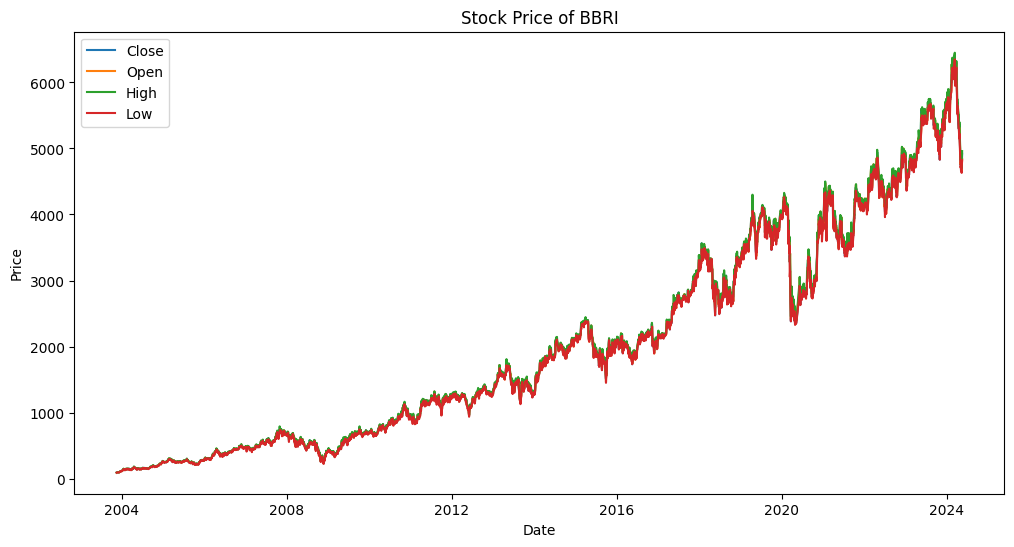

C:\Users\muham\AppData\Local\Temp\ipykernel_23760\2430435871.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bbri['Growth'] = bbri['Close'].pct_change()
C:\Users\muham\AppData\Local\Temp\ipykernel_23760\2430435871.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bbri['Growth'] = bbri['Growth'] * 100 # Convert to percentage


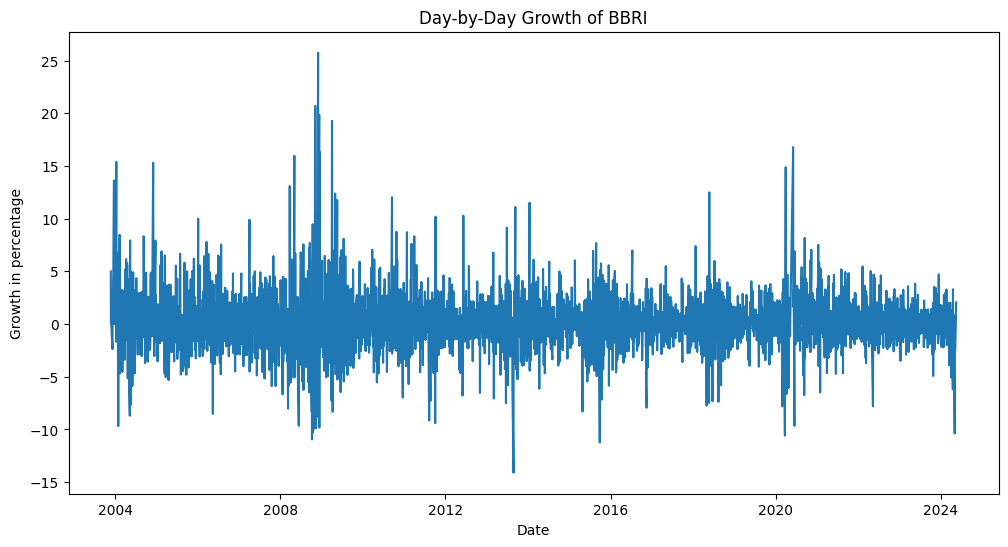

In [26]:
# Line chart for stock price of BBRI
bbri = df_cleaned[df_cleaned['Ticker'] == 'BBRI']
plt.figure(figsize=(12,6))
plt.plot(bbri['Date'], bbri['Close'], label='Close')
plt.plot(bbri['Date'], bbri['Open'], label='Open')
plt.plot(bbri['Date'], bbri['High'], label='High')
plt.plot(bbri['Date'], bbri['Low'], label='Low')
plt.title('Stock Price of BBRI')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

# Line chart for day-by-day growth of BBRI
bbri['Growth'] = bbri['Close'].pct_change()
bbri['Growth'] = bbri['Growth'] * 100 # Convert to percentage
plt.figure(figsize=(12,6))
plt.plot(bbri['Date'], bbri['Growth'])
plt.title('Day-by-Day Growth of BBRI')
plt.xlabel('Date')
plt.ylabel('Growth in percentage')
plt.show()

<Axes: xlabel='Year'>

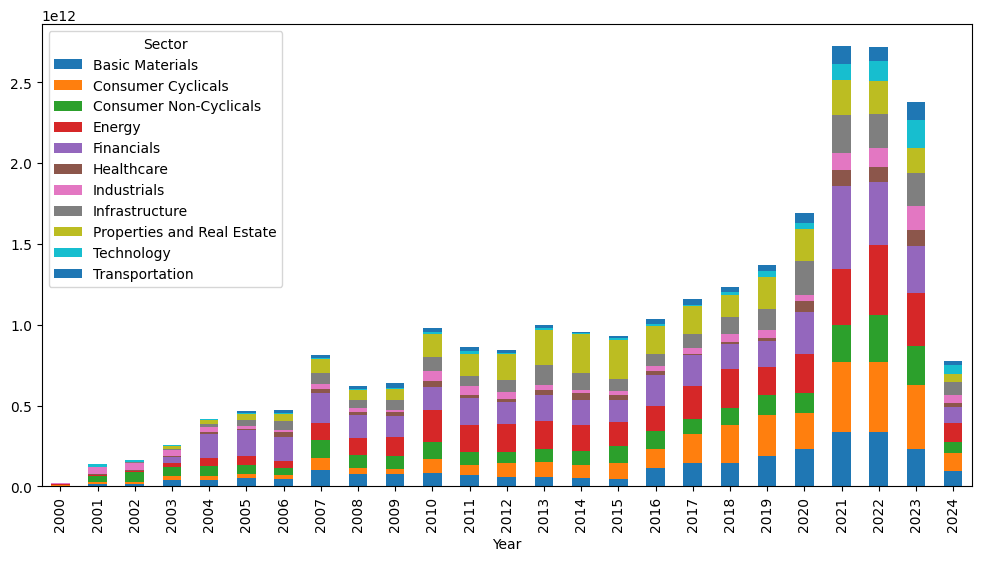

In [27]:
# Barchart of total trading volume of each sector by year from 2019-2024
df_cleaned['Year'] = df_cleaned['Date'].dt.year
df_cleaned['Volume'] = df_cleaned['Volume'].astype('int64')

df_cleaned.groupby(['Year', 'Sector'])['Volume'].sum().unstack().plot(kind='bar', stacked=True, figsize=(12,6))



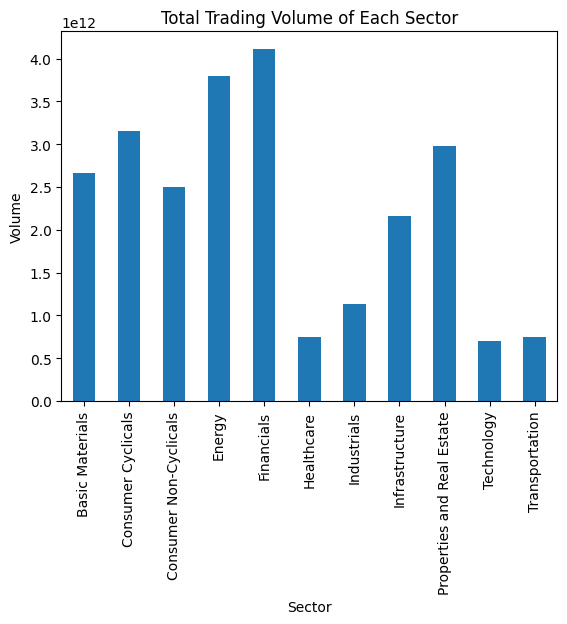

In [28]:

# Barchart of total trading volume of each sector
df_cleaned['Sector'] = df_cleaned['Ticker'].map(stock2sector)
sector_volume = df_cleaned.groupby('Sector')['Volume'].sum()
sector_volume.plot(kind='bar')
plt.title('Total Trading Volume of Each Sector')
plt.xlabel('Sector')
plt.ylabel('Volume')
plt.show()

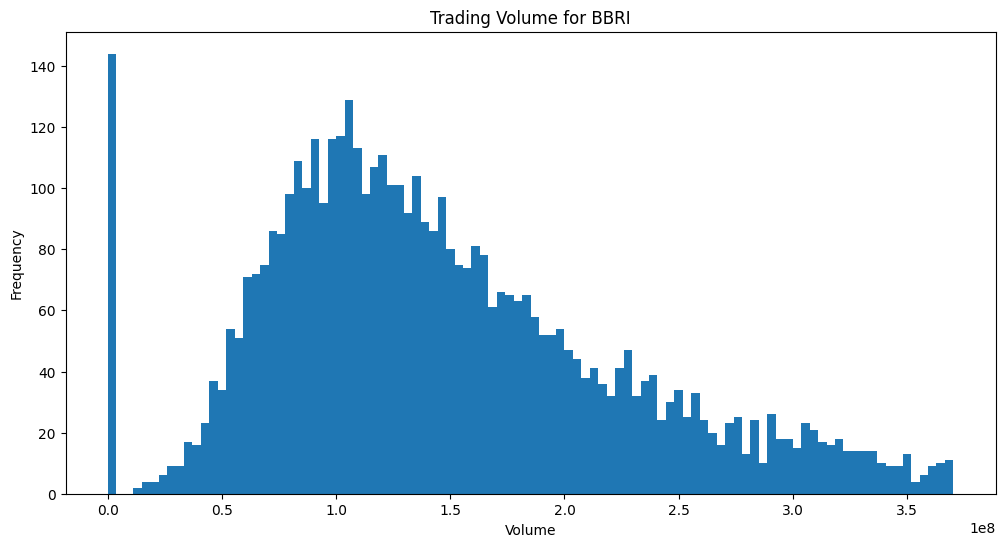

In [29]:
# Histogram of cumulative trading volume for BBRI
filtered = df_cleaned[df_cleaned["Ticker"] == "BBRI"]
plt.figure(figsize=(12,6))
plt.hist(filtered["Volume"], bins=100)
plt.title('Trading Volume for BBRI')
plt.xlabel('Volume')
plt.ylabel('Frequency')
plt.show()

C:\Users\muham\AppData\Local\Temp\ipykernel_23760\1494642041.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered['Year'] = filtered['Date'].dt.year


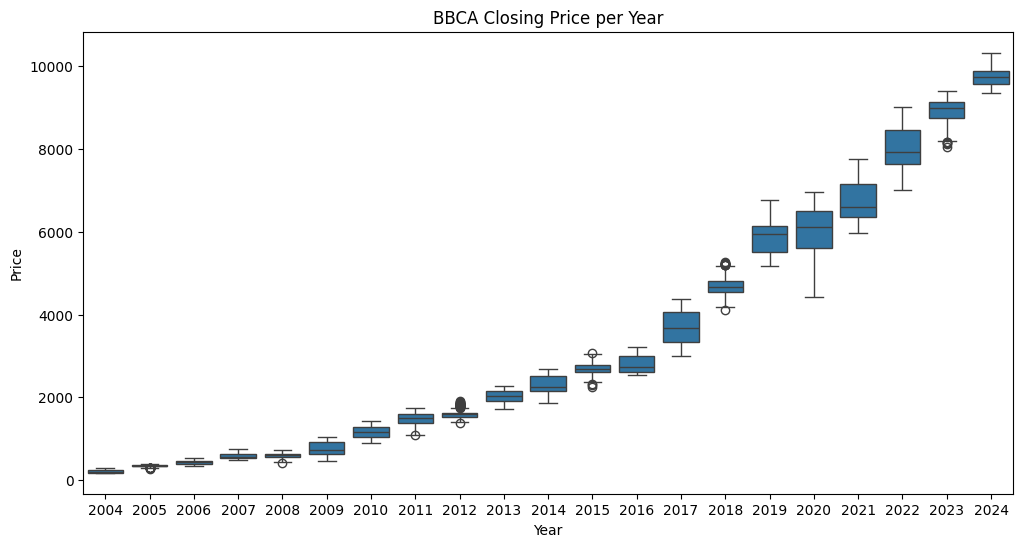

In [30]:
# Box plot of BBRI closing price per year
filtered = df_cleaned[df_cleaned["Ticker"] == "BBCA"]
filtered['Year'] = filtered['Date'].dt.year
plt.figure(figsize=(12,6))
sns.boxplot(x='Year', y='Close', data=filtered)
plt.title('BBCA Closing Price per Year')
plt.xlabel('Year')
plt.ylabel('Price')
plt.show()

Text(0.5, 1.0, 'Total Trading Volume of Each Sector')

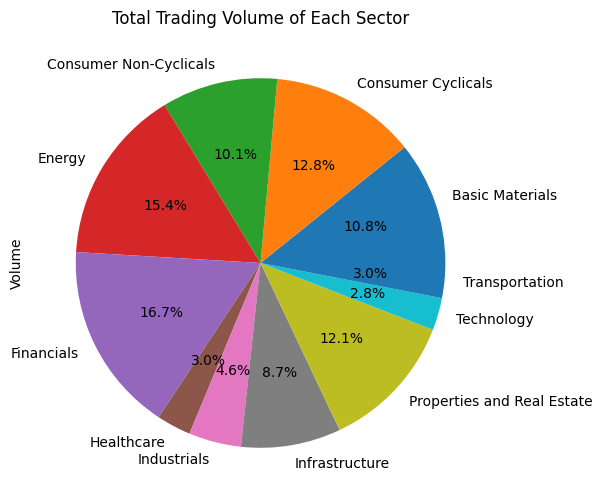

In [31]:
# Pie chart of total trading volume of each sector
sector_volume.plot(kind='pie', autopct='%1.1f%%', figsize=(12,6))
plt.title('Total Trading Volume of Each Sector')


Text(0.5, 1.0, 'Total Sector Value of Each Sector')

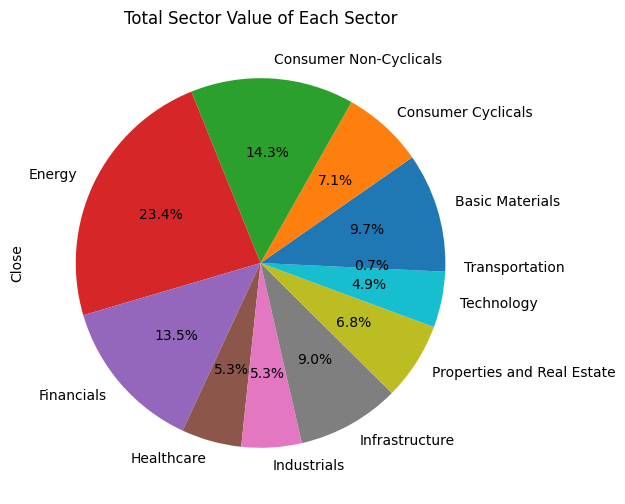

In [32]:
#Pie chart of total sector value (sum of last close price) of each sector
last_close_price = df_cleaned.groupby('Ticker').last()
last_close_price['Sector'] = last_close_price.index.map(stock2sector)
sector_value = last_close_price.groupby('Sector')['Close'].sum()
sector_value.plot(kind='pie', autopct='%1.1f%%', figsize=(12,6))
plt.title('Total Sector Value of Each Sector')



## Problem 3
*MACHINE LEARNING*

### For machine learning, we'll be comparing random forest and linear regression, but first we will use random forest.

In [9]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, make_scorer

def train_and_tune_rf_regression(train_df, test_df, val_df, target_column, n_iter=10, cv=5):
    try:
        X_train = train_df.drop(target_column, axis=1)
        y_train = train_df[target_column]
        X_val = val_df.drop(target_column, axis=1)
        y_val = val_df[target_column]
        X_test = test_df.drop(target_column, axis=1)
        y_test = test_df[target_column]
        print(X_train)
        print(y_train)
        rf = RandomForestRegressor(random_state=42)
        param_grid = {
            'n_estimators': np.arange(50, 251, 50),
            'max_depth': [None, 10, 20],
            'min_samples_split': np.arange(2, 11, 2),
            'min_samples_leaf': np.arange(1, 11),
            'max_features': ['sqrt', 'log2'],
            'bootstrap': [True, False]
        }

        r2_scorer = make_scorer(r2_score)

        rf_random = RandomizedSearchCV(estimator=rf, param_distributions=param_grid,
                                      n_iter=n_iter, cv=cv, random_state=42, n_jobs=-1, scoring=r2_scorer)
        rf_random.fit(X_train, y_train)

        best_rf = rf_random.best_estimator_
        best_params = rf_random.best_params_

        train_r2 = r2_score(y_train, best_rf.predict(X_train))
        val_r2 = r2_score(y_val, best_rf.predict(X_val))
        test_r2 = r2_score(y_test, best_rf.predict(X_test))
        oob_r2 = best_rf.oob_score_ if best_rf.oob_score else None

        return {
            'model': best_rf,
            'best_params': best_params,
            'train_r2': train_r2,
            'val_r2': val_r2,
            'test_r2': test_r2,
            'oob_r2': oob_r2,
            'model': best_rf
        }

    except (ValueError, KeyError) as e:
        print(f"Error: {e}")
        return None


def split_dataframe(df, ratio1, ratio2):
    if not (0 < ratio1 < 1) or not (0 < ratio2 < 1) or (ratio1 + ratio2 >= 1):
        raise ValueError("Ratios must be between 0 and 1 and their sum must be less than 1.")

    n = len(df)
    split1 = int(n * ratio1)
    split2 = int(n * (ratio1 + ratio2))

    df1 = df.iloc[:split1]
    df2 = df.iloc[split1:split2]
    df3 = df.iloc[split2:]

    return df1, df2, df3

In [10]:
df_filtered = df_cleaned[df_cleaned['Sector'] == 'Financials'].head(100000)
ml_df = df_filtered[["Open","Close"]]
train_df, test_df, val_df = split_dataframe(ml_df, 0.6, 0.3)
print("TRAIN: " + str(len(train_df)))
print("TEST: " + str(len(test_df)))
print("VAL: " + str(len(val_df)))
resultRF = train_and_tune_rf_regression(train_df, test_df,val_df, "Close", n_iter=50, cv=15)
modelRF = resultRF['model']
resultRF


TRAIN: 60000
TEST: 29999
VAL: 10001
              Open
10362   194.443802
10363   152.777267
10364   166.666107
10365   166.666107
10366   166.666107
...            ...
247730   94.126762
247731   94.126762
247732   94.126762
247733   94.126762
247734   94.126762

[60000 rows x 1 columns]
10362     152.777267
10363     152.777267
10364     166.666107
10365     166.666107
10366     166.666107
             ...    
247730     94.126762
247731     97.747025
247732     94.126762
247733     94.126762
247734     94.126762
Name: Close, Length: 60000, dtype: float64


{'model': RandomForestRegressor(max_depth=10, max_features='sqrt',
                       min_samples_leaf=np.int64(6),
                       min_samples_split=np.int64(8), n_estimators=np.int64(250),
                       random_state=42),
 'best_params': {'n_estimators': np.int64(250),
  'min_samples_split': np.int64(8),
  'min_samples_leaf': np.int64(6),
  'max_features': 'sqrt',
  'max_depth': 10,
  'bootstrap': True},
 'train_r2': 0.9996612968273535,
 'val_r2': 0.9985550607290351,
 'test_r2': 0.9995396034750099,
 'oob_r2': None}

In [11]:
df_filtered = df_cleaned[df_cleaned['Sector'] == 'Financials'].head(100000)
ml_df = df_filtered[["Ticker"]]
test_df, test_df, val_df = split_dataframe(ml_df, 0.6, 0.3)
val_df["Ticker"].unique()

array(['BBNI', 'BBRI', 'BBSI'], dtype=object)

TRAIN: 2847
TEST: 1424
VAL: 475
Train MSE: 321.9546069737296
Test MSE: 3612.33151986975
Val MSE: 4602.103310498791
Train R2: 0.999204833743755
Test R2: 0.9928976766847646
Val R2: 0.9851035719174784


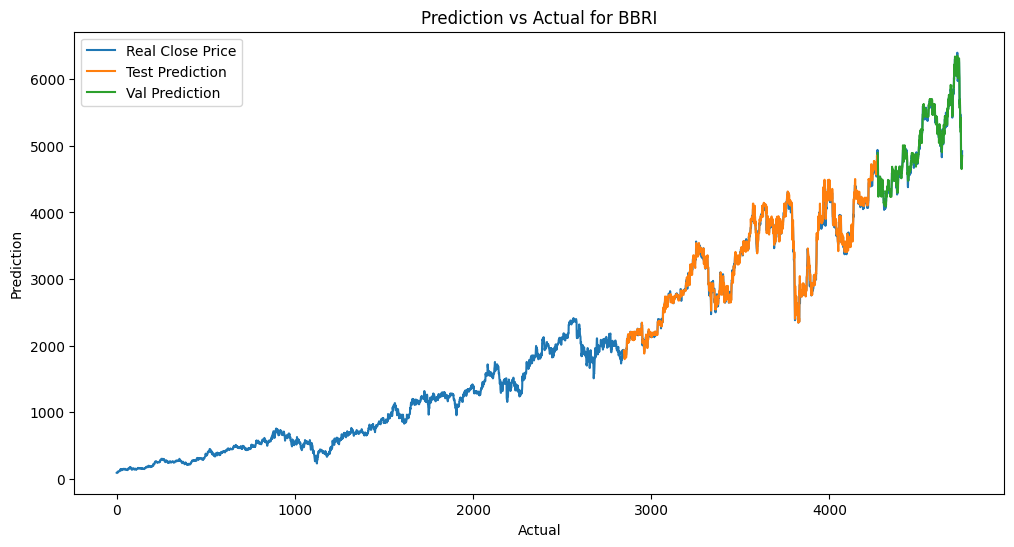

In [12]:
# 2nd test
df_filtered2 = df_cleaned[df_cleaned['Ticker'] == 'BBRI']
ml_df = df_filtered2[["Open","Close"]]
train_df, test_df, val_df = split_dataframe(ml_df, 0.6, 0.3)
print("TRAIN: " + str(len(train_df)))
print("TEST: " + str(len(test_df)))
print("VAL: " + str(len(val_df)))

# check the trained model with only one company
train_predict = modelRF.predict(train_df.drop("Close", axis=1))
test_predict = modelRF.predict(test_df.drop("Close", axis=1))
val_predict = modelRF.predict(val_df.drop("Close", axis=1))
plt.figure(figsize=(12,6))
plt.plot(range(len(df_filtered2)), df_filtered2["Close"], label='Real Close Price')
plt.plot(range(len(train_df), len(train_df) + len(test_df)), test_predict, label='Test Prediction')
plt.plot(range(len(train_df) + len(test_df), len(train_df) + len(test_df) + len(val_df)), val_predict, label='Val Prediction')
plt.title('Prediction vs Actual for BBRI')
plt.xlabel('Actual')
plt.ylabel('Prediction')
plt.legend()

# MSE and R2
from sklearn.metrics import mean_squared_error

train_mse = mean_squared_error(train_df["Close"], train_predict)
test_mse = mean_squared_error(test_df["Close"], test_predict)
val_mse = mean_squared_error(val_df["Close"], val_predict)

train_r2 = r2_score(train_df["Close"], train_predict)
test_r2 = r2_score(test_df["Close"], test_predict)
val_r2 = r2_score(val_df["Close"], val_predict)

print("Train MSE: " + str(train_mse))
print("Test MSE: " + str(test_mse))
print("Val MSE: " + str(val_mse))

print("Train R2: " + str(train_r2))
print("Test R2: " + str(test_r2))
print("Val R2: " + str(val_r2))

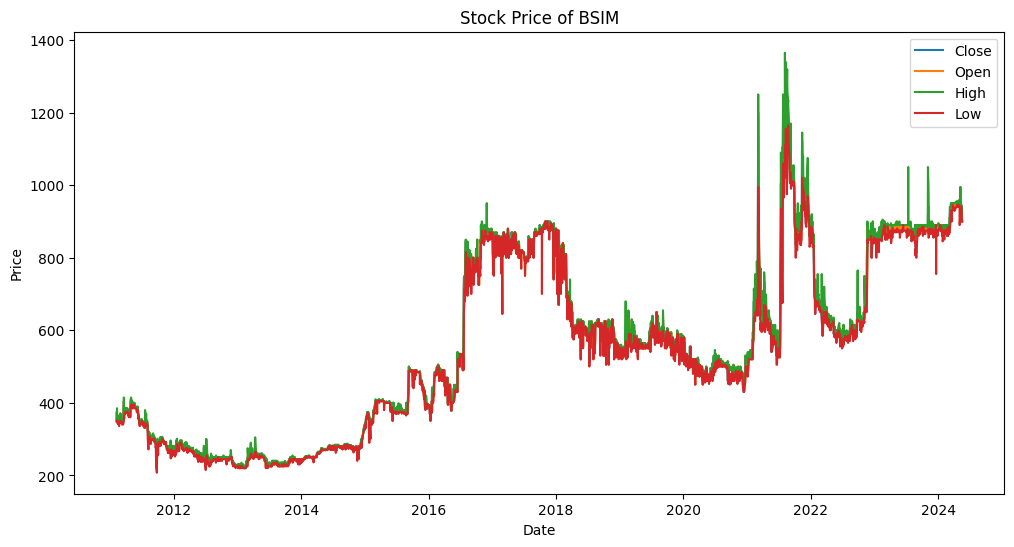

In [53]:
bbri = df_cleaned[df_cleaned['Ticker'] == 'BSIM']
plt.figure(figsize=(12,6))
plt.plot(bbri['Date'], bbri['Close'], label='Close')
plt.plot(bbri['Date'], bbri['Open'], label='Open')
plt.plot(bbri['Date'], bbri['High'], label='High')
plt.plot(bbri['Date'], bbri['Low'], label='Low')
plt.title('Stock Price of BSIM')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

TRAIN: 1410
TEST: 705
VAL: 236
Train MSE: 14309.776463810156
Test MSE: 1815.1072845830404
Val MSE: 2325.0051014500555
Train R2: 0.9972920817185762
Test R2: 0.9678000284521485
Val R2: 0.9515448542927741


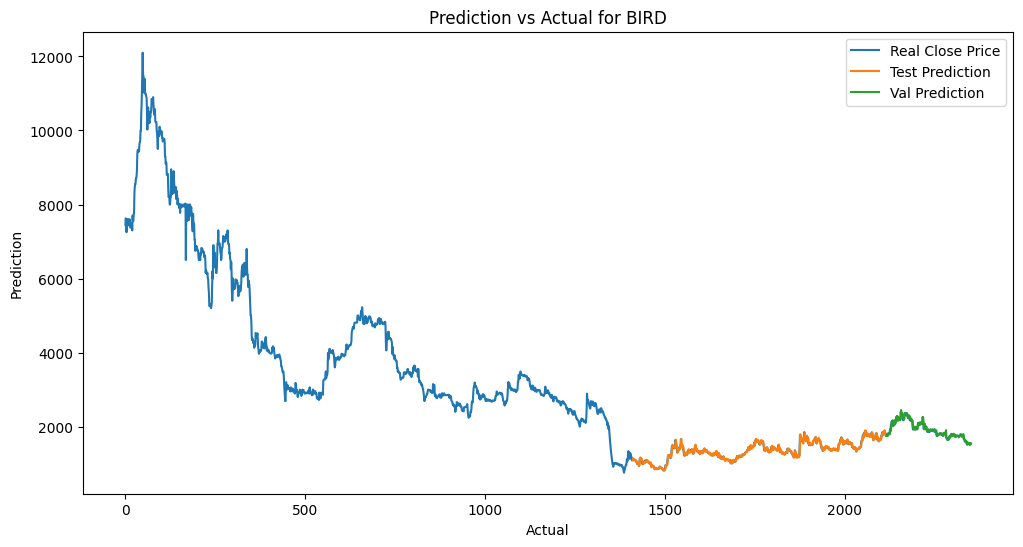

In [13]:
# 3rd test
df_filtered2 = df_cleaned[df_cleaned['Ticker'] == 'BIRD']
ml_df = df_filtered2[["Open","Close"]]
train_df, test_df, val_df = split_dataframe(ml_df, 0.6, 0.3)
print("TRAIN: " + str(len(train_df)))
print("TEST: " + str(len(test_df)))
print("VAL: " + str(len(val_df)))

# check the trained model with only one company
train_predict = modelRF.predict(train_df.drop("Close", axis=1))
test_predict = modelRF.predict(test_df.drop("Close", axis=1))
val_predict = modelRF.predict(val_df.drop("Close", axis=1))
plt.figure(figsize=(12,6))
plt.plot(range(len(df_filtered2)), df_filtered2["Close"], label='Real Close Price')
plt.plot(range(len(train_df), len(train_df) + len(test_df)), test_predict, label='Test Prediction')
plt.plot(range(len(train_df) + len(test_df), len(train_df) + len(test_df) + len(val_df)), val_predict, label='Val Prediction')
plt.title('Prediction vs Actual for BIRD')
plt.xlabel('Actual')
plt.ylabel('Prediction')
plt.legend()


train_mse = mean_squared_error(train_df["Close"], train_predict)
test_mse = mean_squared_error(test_df["Close"], test_predict)
val_mse = mean_squared_error(val_df["Close"], val_predict)

train_r2 = r2_score(train_df["Close"], train_predict)
test_r2 = r2_score(test_df["Close"], test_predict)
val_r2 = r2_score(val_df["Close"], val_predict)

print("Train MSE: " + str(train_mse))
print("Test MSE: " + str(test_mse))
print("Val MSE: " + str(val_mse))

print("Train R2: " + str(train_r2))
print("Test R2: " + str(test_r2))
print("Val R2: " + str(val_r2))

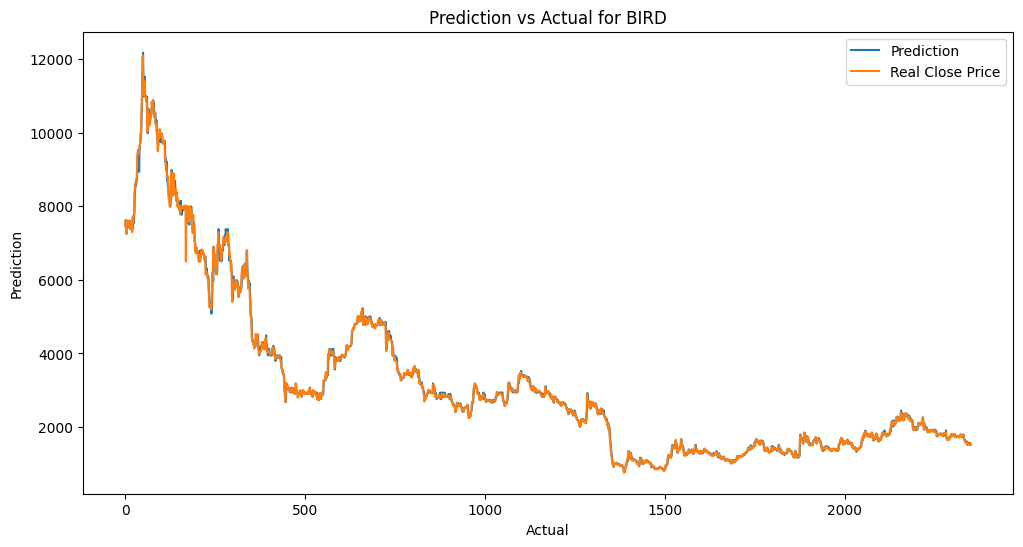

In [18]:
# 3rd test
df_filtered2 = df_cleaned[df_cleaned['Ticker'] == 'BIRD']
ml_df = df_filtered2[["Open","Close"]]

# check the trained model with only one company
train_predict = modelRF.predict(ml_df.drop("Close", axis=1))
plt.figure(figsize=(12,6))
plt.plot(range(len(df_filtered2)), train_predict, label='Prediction')
plt.plot(range(len(df_filtered2)), df_filtered2["Close"], label='Real Close Price')
plt.title('Prediction vs Actual for BIRD')
plt.xlabel('Actual')
plt.ylabel('Prediction')
plt.legend()


## Problem 4

*LINEAR REGRESSION*

In [27]:
from sklearn.linear_model import LinearRegression

def train_and_tune_linear_regression(train_df, val_df, test_df, target_column, cv=5):

    try:
        X_train = train_df.drop(target_column, axis=1)
        y_train = train_df[target_column]
        X_val = val_df.drop(target_column, axis=1)
        y_val = val_df[target_column]
        X_test = test_df.drop(target_column, axis=1)
        y_test = test_df[target_column]

        lr = LinearRegression()

        # Linear Regression doesn't really need hyperparameter tuning, but we can use cross validation to evaluate it
        r2_scorer = make_scorer(r2_score)

        param_grid = {'fit_intercept': [True, False]}
        lr_random = RandomizedSearchCV(estimator=lr, param_distributions=param_grid,
                                      n_iter=1, cv=cv, random_state=42, n_jobs=-1, scoring=r2_scorer)
        lr_random.fit(X_train, y_train)

        best_lr = lr_random.best_estimator_

        train_r2 = r2_score(y_train, best_lr.predict(X_train))
        val_r2 = r2_score(y_val, best_lr.predict(X_val))
        test_r2 = r2_score(y_test, best_lr.predict(X_test))

        return {
            'model': best_lr,
            'train_r2': train_r2,
            'val_r2': val_r2,
            'test_r2': test_r2
        }

    except (ValueError, KeyError) as e:
        print(f"Error: {e}")
        return None

In [28]:
df_filtered = df_cleaned[df_cleaned['Sector'] == 'Financials'].head(100000)
ml_df = df_filtered[["Open","Close"]]
train_df, test_df, val_df = split_dataframe(ml_df, 0.6, 0.3)
print("TRAIN: " + str(len(train_df)))
print("TEST: " + str(len(test_df)))
print("VAL: " + str(len(val_df)))
resultSimple = train_and_tune_linear_regression(train_df, test_df,val_df, "Close", cv=15)
modelSimple = resultSimple['model']
resultSimple

TRAIN: 60000
TEST: 29999
VAL: 10001


{'model': LinearRegression(fit_intercept=False),
 'train_r2': 0.9996097019538078,
 'val_r2': 0.9995923286322069,
 'test_r2': 0.9987483404442644}

In [40]:
df_filtered = df_cleaned[df_cleaned['Sector'] == 'Financials'].head(100000)
ml_df = df_filtered[["Open","Volume","Close"]]
train_df, test_df, val_df = split_dataframe(ml_df, 0.6, 0.3)
print("TRAIN: " + str(len(train_df)))
print("TEST: " + str(len(test_df)))
print("VAL: " + str(len(val_df)))
resultMultiple = train_and_tune_linear_regression(train_df, test_df,val_df, "Close", cv=15)
modelMultiple = resultMultiple['model']
resultMultiple

TRAIN: 60000
TEST: 29999
VAL: 10001


{'model': LinearRegression(fit_intercept=False),
 'train_r2': 0.9996102749644659,
 'val_r2': 0.999581923230061,
 'test_r2': 0.9986628593085837}

TRAIN: 3416
TEST: 1708
VAL: 570
Train MSE: 85.15353151705271
Test MSE: 8316.151678116217
Val MSE: 1674.1139204041795
Train R2: 0.9990898060193413
Test R2: 0.9896452211057153
Val R2: 0.9902649685076027


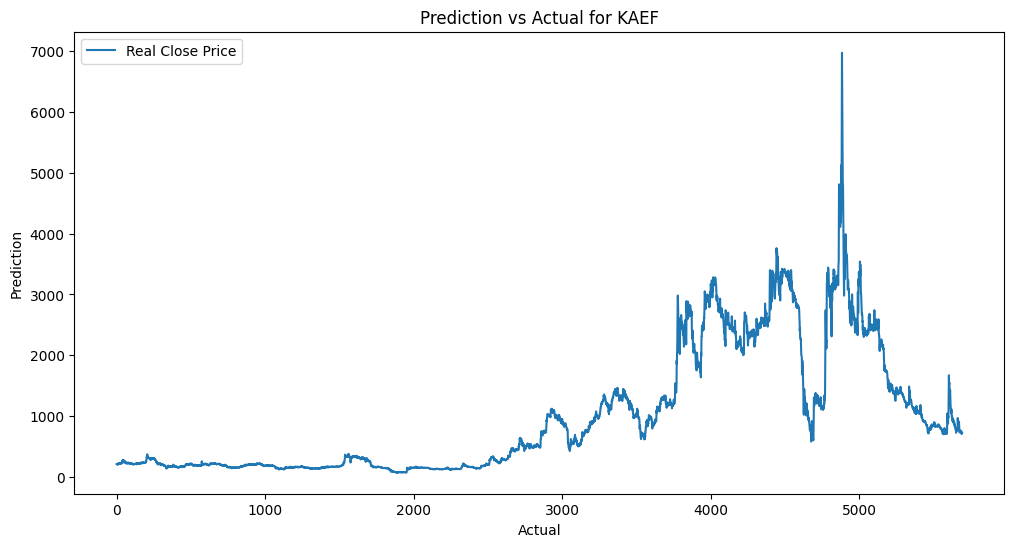

In [58]:
# 2nd test
df_filtered2 = df_cleaned[df_cleaned['Ticker'] == 'KAEF']
ml_df = df_filtered2[["Open","Volume","Close"]]
train_df, test_df, val_df = split_dataframe(ml_df, 0.6, 0.3)
print("TRAIN: " + str(len(train_df)))
print("TEST: " + str(len(test_df)))
print("VAL: " + str(len(val_df)))

# check the trained model with only one company
train_predict = modelMultiple.predict(train_df.drop("Close", axis=1))
test_predict = modelMultiple.predict(test_df.drop("Close", axis=1))
val_predict = modelMultiple.predict(val_df.drop("Close", axis=1))
plt.figure(figsize=(12,6))
plt.plot(range(len(df_filtered2)), df_filtered2["Close"], label='Real Close Price')
plt.plot(range(len(train_df), len(train_df) + len(test_df)), test_predict, label='Test Prediction')
plt.plot(range(len(train_df) + len(test_df), len(train_df) + len(test_df) + len(val_df)), val_predict, label='Val Prediction')
plt.title('Prediction vs Actual for KAEF')
plt.xlabel('Actual')
plt.ylabel('Prediction')
plt.legend()

# MSE and R2
from sklearn.metrics import mean_squared_error

train_mse = mean_squared_error(train_df["Close"], train_predict)
test_mse = mean_squared_error(test_df["Close"], test_predict)
val_mse = mean_squared_error(val_df["Close"], val_predict)

train_r2 = r2_score(train_df["Close"], train_predict)
test_r2 = r2_score(test_df["Close"], test_predict)
val_r2 = r2_score(val_df["Close"], val_predict)

print("Train MSE: " + str(train_mse))
print("Test MSE: " + str(test_mse))
print("Val MSE: " + str(val_mse))

print("Train R2: " + str(train_r2))
print("Test R2: " + str(test_r2))
print("Val R2: " + str(val_r2))

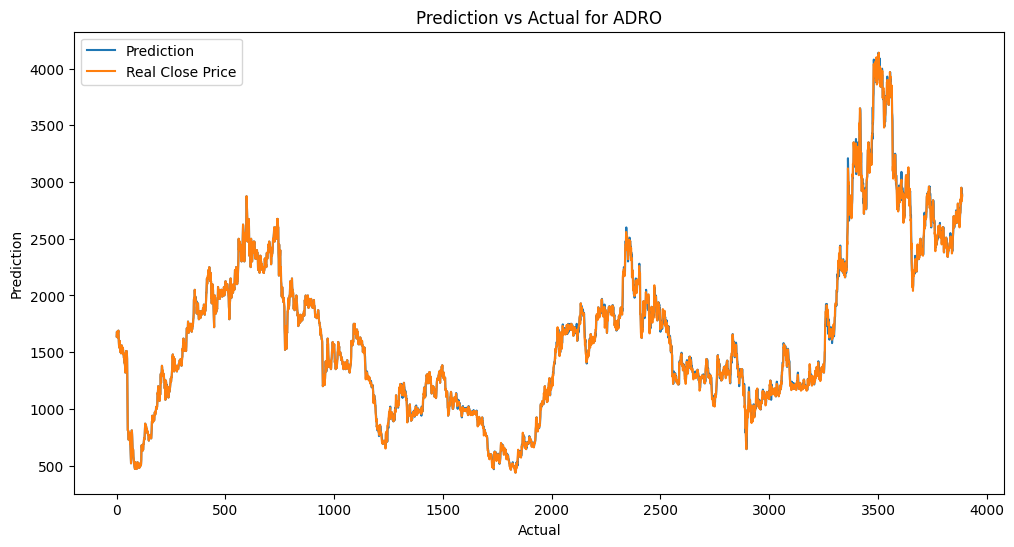

In [37]:
df_filtered2 = df_cleaned[df_cleaned['Ticker'] == 'ADRO']
ml_df = df_filtered2[["Open","Close"]]

# check the trained model with only one company
train_predict = modelSimple.predict(ml_df.drop("Close", axis=1))
plt.figure(figsize=(12,6))
plt.plot(range(len(df_filtered2)), train_predict, label='Prediction')
plt.plot(range(len(df_filtered2)), df_filtered2["Close"], label='Real Close Price')
plt.title('Prediction vs Actual for ADRO')
plt.xlabel('Actual')
plt.ylabel('Prediction')
plt.legend()

In [203]:
# 4th test (RF intra-sector)

# Evaluate accuracy for specific sectors
sectors = df_cleaned['Sector'].unique()
def evaluate(model, totest, modellabel, evaluationlabel):
    totalamount = 0
    companies = df_cleaned[df_cleaned['Sector'].isin(totest)]['Ticker'].unique()
    resultmatrix = pd.DataFrame(columns=["Company", "Test R2", "Test MSE", "Sector", "Highest Difference", "Highest Difference Percentage", "Average Difference", "Average Difference Percentage", "Model", "Evaluation"])
    for company in companies:
        df_filtered2 = df_cleaned[df_cleaned['Ticker'] == company]
        totalamount += len(df_filtered2)
        ml_df = df_filtered2[["Open","Close"]]
        """print("TEST: " + str(len(ml_df)))"""
        test_predict = model.predict(ml_df.drop("Close", axis=1))

        test_mse = mean_squared_error(ml_df["Close"], test_predict)
        test_r2 = r2_score(ml_df["Close"], test_predict)

        # Calculate difference
        difference = ml_df["Close"] - test_predict
        highest_difference = difference.max()
        highest_difference_percentage = (difference / ml_df["Close"]).max() * 100
        average_difference = difference.mean()
        average_difference_percentage = (difference / ml_df["Close"]).mean() * 100

        """         print("Average difference: " + str(average_difference))
        print("Average difference percentage: " + str(average_difference_percentage))
        print("Highest difference percentage: " + str(highest_difference_percentage))
        print("Highest difference: " + str(highest_difference))
        print("Test MSE: " + str(test_mse))
        print("Test R2: " + str(test_r2)) """
        resultmatrix = pd.concat([resultmatrix, pd.DataFrame([[company,test_r2, test_mse, stock2sector[company], highest_difference, highest_difference_percentage, average_difference, average_difference_percentage, modellabel,evaluationlabel]], columns=["Company", "Test R2", "Test MSE", "Sector", "Highest Difference", "Highest Difference Percentage", "Average Difference", "Average Difference Percentage", "Model", "Evaluation"])])
        """print("Total amount of data: " + str(totalamount))"""
    return resultmatrix

resultmatrixRFintra = evaluate(modelRF, df_cleaned[df_cleaned["Sector"] == "Financials"]['Sector'].unique(), "Random Forest", "Intra-Sector")
resultmatrixRFintra.to_csv("resultmatrix_RF_Intrasector.csv")
resultmatrixRFinter = evaluate(modelRF, df_cleaned[df_cleaned["Sector"] != "Financials"]['Sector'].unique(), "Random Forest", "Inter-Sector")
resultmatrixRFinter.to_csv("resultmatrix_RF_Intersector.csv")
resultmatrixSimpleintra = evaluate(modelSimple, df_cleaned[df_cleaned["Sector"] == "Financials"]['Sector'].unique(), "Simple Linear Regression", "Intra-Sector")
resultmatrixSimpleintra.to_csv("resultmatrix_Simple_Intrasector.csv")
resultmatrixSimpleinter = evaluate(modelSimple, df_cleaned[df_cleaned["Sector"] != "Financials"]['Sector'].unique(), "Simple Linear Regression", "Inter-Sector")
resultmatrixSimpleinter.to_csv("resultmatrix_Simple_Intersector.csv")

C:\Users\muham\AppData\Local\Temp\ipykernel_23760\152309853.py:36: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  resultmatrix = pd.concat([resultmatrix, pd.DataFrame([[company,test_r2, test_mse, stock2sector[company], highest_difference, highest_difference_percentage, average_difference, average_difference_percentage, modellabel,evaluationlabel]], columns=["Company", "Test R2", "Test MSE", "Sector", "Highest Difference", "Highest Difference Percentage", "Average Difference", "Average Difference Percentage", "Model", "Evaluation"])])
C:\Users\muham\AppData\Local\Temp\ipykernel_23760\152309853.py:36: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer excl

In [172]:
sectors = df_cleaned['Sector'].unique()
def evaluateMLR(model, totest, modellabel, evaluationlabel):
    totalamount = 0
    companies = df_cleaned[df_cleaned['Sector'].isin(totest)]['Ticker'].unique()
    resultmatrix = pd.DataFrame(columns=["Company", "Test R2", "Test MSE", "Sector", "Highest Difference", "Highest Difference Percentage", "Average Difference", "Average Difference Percentage", "Model", "Evaluation"])
    for company in companies:
        df_filtered2 = df_cleaned[df_cleaned['Ticker'] == company]
        totalamount += len(df_filtered2)
        ml_df = df_filtered2[["Open","Volume","Close"]]
        """print("TEST: " + str(len(ml_df)))"""
        test_predict = model.predict(ml_df.drop("Close", axis=1))


        test_mse = mean_squared_error(ml_df["Close"], test_predict)
        test_r2 = r2_score(ml_df["Close"], test_predict)

        # Calculate difference
        difference = ml_df["Close"] - test_predict
        highest_difference = difference.max()
        highest_difference_percentage = (difference / ml_df["Close"]).max() * 100
        average_difference = difference.mean()
        average_difference_percentage = (difference / ml_df["Close"]).mean() * 100

        """         print("Average difference: " + str(average_difference))
        print("Average difference percentage: " + str(average_difference_percentage))
        print("Highest difference percentage: " + str(highest_difference_percentage))
        print("Highest difference: " + str(highest_difference))
        print("Test MSE: " + str(test_mse))
        print("Test R2: " + str(test_r2)) """
        resultmatrix = pd.concat([resultmatrix, pd.DataFrame([[company,test_r2, test_mse, stock2sector[company], highest_difference, highest_difference_percentage, average_difference, average_difference_percentage, modellabel,evaluationlabel]], columns=["Company", "Test R2", "Test MSE", "Sector", "Highest Difference", "Highest Difference Percentage", "Average Difference", "Average Difference Percentage", "Model", "Evaluation"])])
        """print("Total amount of data: " + str(totalamount))"""
    return resultmatrix


resultmatrixMultipleintra = evaluateMLR(modelMultiple, df_cleaned[df_cleaned["Sector"] == "Financials"]['Sector'].unique(), "Multiple Linear Regression", "Intra-Sector")
resultmatrixMultipleintra.to_csv("resultmatrix_Multiple_Intrasector.csv")
resultmatrixMultipleinter = evaluateMLR(modelMultiple, df_cleaned[df_cleaned["Sector"] != "Financials"]['Sector'].unique(), "Multiple Linear Regression", "Inter-Sector")
resultmatrixMultipleinter.to_csv("resultmatrix_Multiple_Intersector.csv")

C:\Users\muham\AppData\Local\Temp\ipykernel_23760\175055781.py:33: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  resultmatrix = pd.concat([resultmatrix, pd.DataFrame([[company,test_r2, test_mse, stock2sector[company], highest_difference, highest_difference_percentage, average_difference, average_difference_percentage, modellabel,evaluationlabel]], columns=["Company", "Test R2", "Test MSE", "Sector", "Highest Difference", "Highest Difference Percentage", "Average Difference", "Average Difference Percentage", "Model", "Evaluation"])])
C:\Users\muham\AppData\Local\Temp\ipykernel_23760\175055781.py:33: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer excl

In [22]:
fulldf = pd.DataFrame(columns=["ML Model","Scope","Lowest R2", "Highest R2", "Lowest MSE", "Highest MSE", "Average R2", "Average MSE", "Lowest HD", "Highest HD", "Average HD", "Lowest HDP", "Highest HDP", "Average HDP", "Lowest AD", "Highest AD", "Average AD", "Lowest ADP", "Highest ADP", "Average ADP"])
# Analysis of Accuracy (Highest Difference, Highest Difference Percentage, Average Difference, Average Difference Percentage, R2, MSE)
def accuracyAnalysis(dataset):
    lowestR2 = dataset[dataset["Test R2"] == dataset["Test R2"].min()]
    highestR2 = dataset[dataset["Test R2"] == dataset["Test R2"].max()]
    lowestMSE = dataset[dataset["Test MSE"] == dataset["Test MSE"].min()]
    highestMSE =dataset[dataset["Test MSE"] == dataset["Test MSE"].max()]
    averageR2 = dataset["Test R2"].mean()
    averageMSE =dataset["Test MSE"].mean()
    lowestHD = dataset[dataset["Highest Difference"] == dataset["Highest Difference"].min()]
    highestHD = dataset[dataset["Highest Difference"] == dataset["Highest Difference"].max()]
    averageHD = dataset["Highest Difference"].mean()
    lowestHDP = dataset[dataset["Highest Difference Percentage"] == dataset["Highest Difference Percentage"].min()]
    highestHDP =dataset[dataset["Highest Difference Percentage"] == dataset["Highest Difference Percentage"].max()]
    averageHDP =dataset["Highest Difference Percentage"].mean()
    lowestAD = dataset[dataset["Average Difference"] == dataset["Average Difference"].min()]
    highestAD = dataset[dataset["Average Difference"] == dataset["Average Difference"].max()]
    averageAD = dataset["Average Difference"].mean()
    lowestADP = dataset[dataset["Average Difference Percentage"] == dataset["Average Difference Percentage"].min()]
    highestADP =dataset[dataset["Average Difference Percentage"] == dataset["Average Difference Percentage"].max()]
    averageADP =dataset["Average Difference Percentage"].mean()

    # print all the results
    print("Lowest R2: " + str(lowestR2["Test R2"].values[0]))
    print("Highest R2: " + str(highestR2["Test R2"].values[0]))
    print("Lowest MSE: " + str(lowestMSE["Test MSE"].values[0]))
    print("Highest MSE: " + str(highestMSE["Test MSE"].values[0]))
    print("Average R2: " + str(averageR2))
    print("Average MSE: " + str(averageMSE))
    print("Lowest HD: " + str(lowestHD["Highest Difference"].values[0]))
    print("Highest HD: " + str(highestHD["Highest Difference"].values[0]))
    print("Average HD: " + str(averageHD))
    print("Lowest HDP: " + str(lowestHDP["Highest Difference Percentage"].values[0]))
    print("Highest HDP: " + str(highestHDP["Highest Difference Percentage"].values[0]))
    print("Average HDP: " + str(averageHDP))
    print("Lowest AD: " + str(lowestAD["Average Difference"].values[0]))
    print("Highest AD: " + str(highestAD["Average Difference"].values[0]))
    print("Average AD: " + str(averageAD))
    print("Lowest ADP: " + str(lowestADP["Average Difference Percentage"].values[0]))
    print("Highest ADP: " + str(highestADP["Average Difference Percentage"].values[0]))
    print("Average ADP: " + str(averageADP))

    return lowestR2, highestR2, lowestMSE, highestMSE, averageR2, averageMSE, lowestHD, highestHD, averageHD, lowestHDP, highestHDP, averageHDP, lowestAD, highestAD, averageAD, lowestADP, highestADP, averageADP
# Random Forest
# Intra-Sector
resultmatrixRFintra = pd.read_csv("resultmatrix_RF_Intrasector.csv")
resultmatrixRFintra = resultmatrixRFintra.drop("Unnamed: 0", axis=1)
lowestR2, highestR2, lowestMSE, highestMSE, averageR2, averageMSE, lowestHD, highestHD, averageHD, lowestHDP, highestHDP, averageHDP, lowestAD, highestAD, averageAD, lowestADP, highestADP, averageADP = accuracyAnalysis(resultmatrixRFintra)
fulldf = pd.concat([fulldf, pd.DataFrame([["Random Forest","Intra-sector", lowestR2["Test R2"].values[0], highestR2["Test R2"].values[0], lowestMSE["Test MSE"].values[0], highestMSE["Test MSE"].values[0], averageR2, averageMSE, lowestHD["Highest Difference"].values[0], highestHD["Highest Difference"].values[0], averageHD, lowestHDP["Highest Difference Percentage"].values[0], highestHDP["Highest Difference Percentage"].values[0], averageHDP, lowestAD["Average Difference"].values[0], highestAD["Average Difference"].values[0], averageAD, lowestADP["Average Difference Percentage"].values[0], highestADP["Average Difference Percentage"].values[0], averageADP]], columns=["ML Model","Scope","Lowest R2", "Highest R2", "Lowest MSE", "Highest MSE", "Average R2", "Average MSE", "Lowest HD", "Highest HD", "Average HD", "Lowest HDP", "Highest HDP", "Average HDP", "Lowest AD", "Highest AD", "Average AD", "Lowest ADP", "Highest ADP", "Average ADP"])])



Lowest R2: 0.6622864336654107
Highest R2: 0.9995701301291156
Lowest MSE: 2.9562352660528743
Highest MSE: 34157.06211846899
Average R2: 0.9890933141504141
Average MSE: 1900.9540825215277
Lowest HD: 27.839607814184404
Highest HD: 2866.479902754625
Average HD: 346.3964432464902
Lowest HDP: 11.195492335753208
Highest HDP: 82.7988078491698
Average HDP: 26.901582433862902
Lowest AD: -10.150675549852853
Highest AD: 7.943388675553985
Average AD: -0.12363127421218686
Lowest ADP: -10.771199758173546
Highest ADP: 0.2891989863006785
Average ADP: -0.34169904690932146


C:\Users\muham\AppData\Local\Temp\ipykernel_22840\2373234082.py:49: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  fulldf = pd.concat([fulldf, pd.DataFrame([["Random Forest","Intra-sector", lowestR2["Test R2"].values[0], highestR2["Test R2"].values[0], lowestMSE["Test MSE"].values[0], highestMSE["Test MSE"].values[0], averageR2, averageMSE, lowestHD["Highest Difference"].values[0], highestHD["Highest Difference"].values[0], averageHD, lowestHDP["Highest Difference Percentage"].values[0], highestHDP["Highest Difference Percentage"].values[0], averageHDP, lowestAD["Average Difference"].values[0], highestAD["Average Difference"].values[0], averageAD, lowestADP["Average Difference Percentage"].values[0], highestADP["Average Difference Percentage

In [21]:
# Inter-Sector
resultmatrixRFinter = pd.read_csv("resultmatrix_RF_Intersector.csv")
resultmatrixRFinter = resultmatrixRFinter.drop("Unnamed: 0", axis=1)
lowestR2, highestR2, lowestMSE, highestMSE, averageR2, averageMSE, lowestHD, highestHD, averageHD, lowestHDP, highestHDP, averageHDP, lowestAD, highestAD, averageAD, lowestADP, highestADP, averageADP = accuracyAnalysis(resultmatrixRFinter)
fulldf = pd.concat([fulldf, pd.DataFrame([["Random Forest","Inter-sector", lowestR2["Test R2"].values[0], highestR2["Test R2"].values[0], lowestMSE["Test MSE"].values[0], highestMSE["Test MSE"].values[0], averageR2, averageMSE, lowestHD["Highest Difference"].values[0], highestHD["Highest Difference"].values[0], averageHD, lowestHDP["Highest Difference Percentage"].values[0], highestHDP["Highest Difference Percentage"].values[0], averageHDP, lowestAD["Average Difference"].values[0], highestAD["Average Difference"].values[0], averageAD, lowestADP["Average Difference Percentage"].values[0], highestADP["Average Difference Percentage"].values[0], averageADP]], columns=["ML Model","Scope","Lowest R2", "Highest R2", "Lowest MSE", "Highest MSE", "Average R2", "Average MSE", "Lowest HD", "Highest HD", "Average HD", "Lowest HDP", "Highest HDP", "Average HDP", "Lowest AD", "Highest AD", "Average AD", "Lowest ADP", "Highest ADP", "Average ADP"])])


Lowest R2: -2.347766932195281
Highest R2: 0.9998805267769622
Lowest MSE: 0.5314420075934382
Highest MSE: 797754612.4292368
Average R2: 0.9602703255870008
Average MSE: 2461784.7547981106
Lowest HD: -81.99685571707414
Highest HD: 129427.24769976154
Average HD: 883.0005358506921
Lowest HDP: -43.38457974448367
Highest HDP: 99.6105390456416
Average HDP: 25.39229136354537
Lowest AD: -81.99685571707414
Highest AD: 19418.36501931874
Average AD: 88.7262045079207
Lowest ADP: -292.8638214819957
Highest ADP: 46.444644372016505
Average ADP: -2.139562753658246


In [38]:

# Simple Linear Regression
# Intra-Sector
resultmatrixSimpleintra = pd.read_csv("resultmatrix_Simple_Intrasector.csv")
resultmatrixSimpleintra = resultmatrixSimpleintra.drop("Unnamed: 0", axis=1)
lowestR2, highestR2, lowestMSE, highestMSE, averageR2, averageMSE, lowestHD, highestHD, averageHD, lowestHDP, highestHDP, averageHDP, lowestAD, highestAD, averageAD, lowestADP, highestADP, averageADP = accuracyAnalysis(resultmatrixSimpleintra)
fulldf = pd.concat([fulldf, pd.DataFrame([["Simple Linear Regression","Intra-sector", lowestR2["Test R2"].values[0], highestR2["Test R2"].values[0], lowestMSE["Test MSE"].values[0], highestMSE["Test MSE"].values[0], averageR2, averageMSE, lowestHD["Highest Difference"].values[0], highestHD["Highest Difference"].values[0], averageHD, lowestHDP["Highest Difference Percentage"].values[0], highestHDP["Highest Difference Percentage"].values[0], averageHDP, lowestAD["Average Difference"].values[0], highestAD["Average Difference"].values[0], averageAD, lowestADP["Average Difference Percentage"].values[0], highestADP["Average Difference Percentage"].values[0], averageADP]], columns=["ML Model","Scope","Lowest R2", "Highest R2", "Lowest MSE", "Highest MSE", "Average R2", "Average MSE", "Lowest HD", "Highest HD", "Average HD", "Lowest HDP", "Highest HDP", "Average HDP", "Lowest AD", "Highest AD", "Average AD", "Lowest ADP", "Highest ADP", "Average ADP"])])


Lowest R2: 0.7309958576147806
Highest R2: 0.9996121021886024
Lowest MSE: 2.4885208782541737
Highest MSE: 42225.00808362203
Average R2: 0.9899017680900151
Average MSE: 1899.2293198171487
Lowest HD: 28.016468543360148
Highest HD: 2877.6040004458373
Average HD: 348.666600934281
Lowest HDP: 11.123620252183226
Highest HDP: 100.0
Average HDP: 27.105608039593577
Lowest AD: -7.001401369526634
Highest AD: 13.507920157977704
Average AD: 0.4458468142566963
Lowest ADP: -1.113154399092915
Highest ADP: 0.348795956164625
Average ADP: -0.015202664750864566


In [39]:
# Inter-Sector
resultmatrixSimpleinter = pd.read_csv("resultmatrix_Simple_Intersector.csv")
resultmatrixSimpleinter = resultmatrixSimpleinter.drop("Unnamed: 0", axis=1)
lowestR2, highestR2, lowestMSE, highestMSE, averageR2, averageMSE, lowestHD, highestHD, averageHD, lowestHDP, highestHDP, averageHDP, lowestAD, highestAD, averageAD, lowestADP, highestADP, averageADP = accuracyAnalysis(resultmatrixSimpleinter)
fulldf = pd.concat([fulldf, pd.DataFrame([["Simple Linear Regression","Inter-sector", lowestR2["Test R2"].values[0], highestR2["Test R2"].values[0], lowestMSE["Test MSE"].values[0], highestMSE["Test MSE"].values[0], averageR2, averageMSE, lowestHD["Highest Difference"].values[0], highestHD["Highest Difference"].values[0], averageHD, lowestHDP["Highest Difference Percentage"].values[0], highestHDP["Highest Difference Percentage"].values[0], averageHDP, lowestAD["Average Difference"].values[0], highestAD["Average Difference"].values[0], averageAD, lowestADP["Average Difference Percentage"].values[0], highestADP["Average Difference Percentage"].values[0], averageADP]], columns=["ML Model","Scope","Lowest R2", "Highest R2", "Lowest MSE", "Highest MSE", "Average R2", "Average MSE", "Lowest HD", "Highest HD", "Average HD", "Lowest HDP", "Highest HDP", "Average HDP", "Lowest AD", "Highest AD", "Average AD", "Lowest ADP", "Highest ADP", "Average ADP"])])


Lowest R2: -0.6250136101699499
Highest R2: 0.9999736259693038
Lowest MSE: 0.4113018627583135
Highest MSE: 1312594.698740649
Average R2: 0.9726958653111485
Average MSE: 6048.849975153711
Lowest HD: -80.96199566916886
Highest HD: 13468.89659782991
Average HD: 352.72230947832844
Lowest HDP: -42.83703474559199
Highest HDP: 100.0
Average HDP: 25.60927410625481
Lowest AD: -80.96199566916886
Highest AD: 92.42883286910862
Average AD: 0.3817198445720807
Lowest ADP: -42.83703474559199
Highest ADP: 2.7553203700762414
Average ADP: -0.11253320766770904


In [59]:

# Multiple Linear Regression
# Intra-Sector
resultmatrixMultipleintra = pd.read_csv("resultmatrix_Multiple_Intrasector.csv")
resultmatrixMultipleintra = resultmatrixMultipleintra.drop("Unnamed: 0", axis=1)
lowestR2, highestR2, lowestMSE, highestMSE, averageR2, averageMSE, lowestHD, highestHD, averageHD, lowestHDP, highestHDP, averageHDP, lowestAD, highestAD, averageAD, lowestADP, highestADP, averageADP = accuracyAnalysis(resultmatrixMultipleintra)
fulldf = pd.concat([fulldf, pd.DataFrame([["Multiple Linear Regression","Intra-sector", lowestR2["Test R2"].values[0], highestR2["Test R2"].values[0], lowestMSE["Test MSE"].values[0], highestMSE["Test MSE"].values[0], averageR2, averageMSE, lowestHD["Highest Difference"].values[0], highestHD["Highest Difference"].values[0], averageHD, lowestHDP["Highest Difference Percentage"].values[0], highestHDP["Highest Difference Percentage"].values[0], averageHDP, lowestAD["Average Difference"].values[0], highestAD["Average Difference"].values[0], averageAD, lowestADP["Average Difference Percentage"].values[0], highestADP["Average Difference Percentage"].values[0], averageADP]], columns=["ML Model","Scope","Lowest R2", "Highest R2", "Lowest MSE", "Highest MSE", "Average R2", "Average MSE", "Lowest HD", "Highest HD", "Average HD", "Lowest HDP", "Highest HDP", "Average HDP", "Lowest AD", "Highest AD", "Average AD", "Lowest ADP", "Highest ADP", "Average ADP"])])


Lowest R2: 0.7306273037960309
Highest R2: 0.9995970407027084
Lowest MSE: 9.579144454253433
Highest MSE: 42076.1168352359
Average R2: 0.9887269226717195
Average MSE: 1909.6261783541106
Lowest HD: 21.00819891874588
Highest HD: 2878.7447568514544
Average HD: 344.13108656808896
Lowest HDP: 5.558620020485073
Highest HDP: 99.70436080729604
Average HDP: 26.219820156344902
Lowest AD: -17.26762797617888
Highest AD: 13.862145310116064
Average AD: -0.7107920295383802
Lowest ADP: -3.786032316064879
Highest ADP: 0.3219579750609022
Average ADP: -0.4029472713573445


In [194]:
# Inter-Sector
resultmatrixMultipleinter = pd.read_csv("resultmatrix_Multiple_Intersector.csv")
resultmatrixMultipleinter = resultmatrixMultipleinter.drop("Unnamed: 0", axis=1)
lowestR2, highestR2, lowestMSE, highestMSE, averageR2, averageMSE, lowestHD, highestHD, averageHD, lowestHDP, highestHDP, averageHDP, lowestAD, highestAD, averageAD, lowestADP, highestADP, averageADP = accuracyAnalysis(resultmatrixMultipleinter)
fulldf = pd.concat([fulldf, pd.DataFrame([["Multiple Linear Regression","Inter-sector", lowestR2["Test R2"].values[0], highestR2["Test R2"].values[0], lowestMSE["Test MSE"].values[0], highestMSE["Test MSE"].values[0], averageR2, averageMSE, lowestHD["Highest Difference"].values[0], highestHD["Highest Difference"].values[0], averageHD, lowestHDP["Highest Difference Percentage"].values[0], highestHDP["Highest Difference Percentage"].values[0], averageHDP, lowestAD["Average Difference"].values[0], highestAD["Average Difference"].values[0], averageAD, lowestADP["Average Difference Percentage"].values[0], highestADP["Average Difference Percentage"].values[0], averageADP]], columns=["ML Model","Scope","Lowest R2", "Highest R2", "Lowest MSE", "Highest MSE", "Average R2", "Average MSE", "Lowest HD", "Highest HD", "Average HD", "Lowest HDP", "Highest HDP", "Average HDP", "Lowest AD", "Highest AD", "Average AD", "Lowest ADP", "Highest ADP", "Average ADP"])])

Lowest R2: -8.232772149944367
Highest R2: 0.9999314756907268
Lowest MSE: 0.5703722629463651
Highest MSE: 1312860.933107505
Average R2: 0.9392861101473164
Average MSE: 6076.4512473195455
Lowest HD: -118.7507962878941
Highest HD: 13477.188339223008
Average HD: 347.7438777252213
Lowest HDP: -62.83110914703392
Highest HDP: 99.99997315690304
Average HDP: 23.21846740040483
Lowest AD: -118.7507962878941
Highest AD: 94.66481789887634
Average AD: -1.2989243563724309
Lowest ADP: -62.83110914703392
Highest ADP: 1.6294423399684326
Average ADP: -1.3493199947588321


In [195]:
fulldf

,ML Model,Scope,Lowest R2,Highest R2,Lowest MSE,Highest MSE,Average R2,Average MSE,Lowest HD,Highest HD,Average HD,Lowest HDP,Highest HDP,Average HDP,Lowest AD,Highest AD,Average AD,Lowest ADP,Highest ADP,Average ADP
0,Random Forest,Intra-sector,0.662286,0.999570,2.956235,3.415706e+04,0.989093,1.900954e+03,27.839608,2866.479903,346.396443,11.195492,82.798808,26.901582,-10.150676,7.943389,-0.123631,-10.771200,0.289199,-0.341699
0,Random Forest,Inter-sector,-2.347767,0.999881,0.531442,7.977546e+08,0.960270,2.461785e+06,-81.996856,129427.247700,883.000536,-43.384580,99.610539,25.392291,-81.996856,19418.365019,88.726205,-292.863821,46.444644,-2.139563
0,Simple Linear Regression,Intra-sector,0.730996,0.999612,2.488521,4.222501e+04,0.989902,1.899229e+03,28.016469,2877.604000,348.666601,11.123620,100.000000,27.105608,-7.001401,13.507920,0.445847,-1.113154,0.348796,-0.015203
0,Simple Linear Regression,Inter-sector,-0.625014,0.999974,0.411302,1.312595e+06,0.972696,6.048850e+03,-80.961996,13468.896598,352.722309,-42.837035,100.000000,25.609274,-80.961996,92.428833,0.381720,-42.837035,2.755320,-0.112533
0,Multiple Linear Regression,Intra-sector,0.730627,0.999597,9.579144,4.207612e+04,0.988727,1.909626e+03,21.008199,2878.744757,344.131087,5.558620,99.704361,26.219820,-17.267628,13.862145,-0.710792,-3.786032,0.321958,-0.402947
0,Multiple Linear Regression,Inter-sector,-8.232772,0.999931,0.570372,1.312861e+06,0.939286,6.076451e+03,-118.750796,13477.188339,347.743878,-62.831109,99.999973,23.218467,-118.750796,94.664818,-1.298924,-62.831109,1.629442,-1.349320


---

In [199]:
studentName2 = "Muhammad Fadhlan"
studentNIM2 = "00000083094"
studentClass2 = "EL"

In [200]:
print("Name: \t\t{}".format(studentName2))
print("NIM: \t\t{}".format(studentNIM2))
print("NIM: \t\t{}".format(studentClass2))
print("End: \t\t{}".format(myDate))
print("Device ID: \t{}".format(myDevice))

Name: 		Muhammad Fadhlan
NIM: 		00000083094
NIM: 		EL
End: 		2024-12-18 18:58:17.755221
Device ID: 	5e781314-bd37-11ef-b047-50ebf62b781d
